In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
from scipy import stats

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [31]:
import re
from collections import Counter


mbon_csv_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
csvfile = pd.read_csv(mbon_csv_path).astype('string')

def find_number(df, lookup, col):
    vals = []
    for _, row in df.iterrows():
        if lookup in [x.strip() for x in row['MBON names'].split(',')]:
            vals.append(row[col])
    return ', '.join(list(set(vals)))

def compress_mbon_label(label):
    parts = [p.strip() for p in label.split(',')]
    if len(parts) <= 1:
        return label
    prefix_match = re.match(r'^([A-Za-z]+)', parts[0])
    if not prefix_match:
        return label
    prefix = prefix_match.group(1)
    numbers = []
    for p in parts:
        m = re.match(r'^' + re.escape(prefix) + r'(\d+.*)$', p.strip())
        if m:
            numbers.append(m.group(1))
        else:
            return label
    return prefix + ', '.join(numbers)

def build_lobelocation(mbons):
    """Build lobelocation DataFrame for a set of MBONs."""
    rows = []
    for m in mbons:
        row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
                'MBON_number': find_number(csvfile, m, "MBON number").strip()}
        rows.append(row)
    return pd.DataFrame(rows)

def rename_labels(mbons, use_mbon_numbers=False):
    """Return list of display labels for MBONs. 
    If use_mbon_numbers=True, converts driver names to MBON numbers.
    If False, returns driver names as-is."""
    if not use_mbon_numbers:
        return list(mbons)
    lobeloc = build_lobelocation(mbons)
    raw_labels = []
    for mbon in mbons:
        info = lobeloc[lobeloc['MBON'] == mbon]
        if len(info) > 0:
            raw_number = str(info['MBON_number'].values[0])
            label = compress_mbon_label(raw_number)
            raw_labels.append(label if label and label != 'nan' else mbon)
        else:
            raw_labels.append(mbon)
    counts = Counter(raw_labels)
    seen = {}
    labels = []
    for label in raw_labels:
        if counts[label] > 1:
            seen[label] = seen.get(label, 0) + 1
            labels.append(f"{label}_{seen[label]}")
        else:
            labels.append(label)
    return labels

# Toggle this to switch labels in any cell that uses rename_labels()
USE_MBON_NUMBERS = False

In [32]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_bothresponders_Full.xlsx"

df = pd.read_excel(filepath)


In [33]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

acr = acr.drop(index=["R76B09", "VT999036"], errors="ignore")
chrimson = chrimson.drop(index=["R76B09", "VT999036"], errors="ignore")

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs() + acr['Max Velocity ratio_Hg_OSAR'].abs()) / 4
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs() + chrimson['Max Velocity ratio_Hg_OSAR'].abs()) / 4

comb_acr = (pref_acr + loco_acr) / 2
comb_chr = (pref_chr + loco_chr) / 2

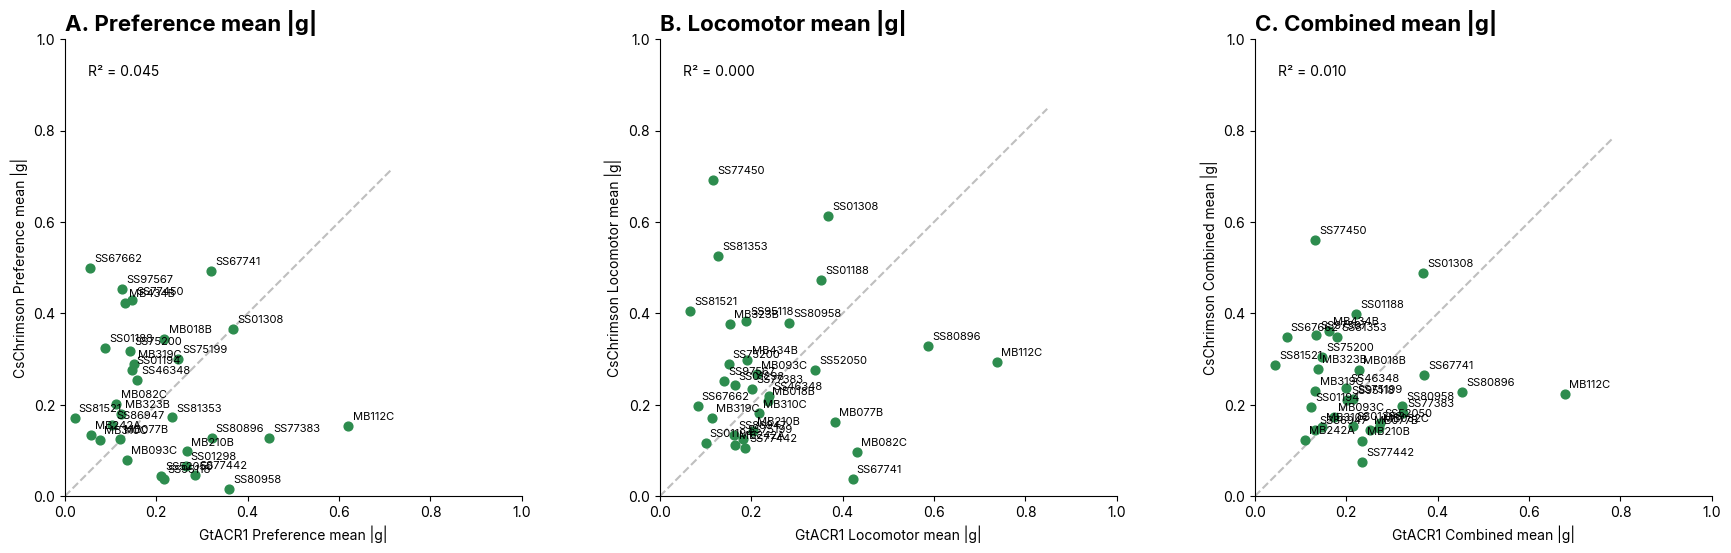

In [5]:
mpl.rcParams['svg.fonttype'] = 'none'
USE_MBON_NUMBERS = False
panels = [
    (pref_acr, pref_chr, 'Preference mean |g|'),
    (loco_acr, loco_chr, 'Locomotor mean |g|'),
    (comb_acr, comb_chr, 'Combined mean |g|'),
]

label_map = dict(zip(mbons, rename_labels(mbons, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (x, y, title), label in zip(axes, panels, ['A', 'B', 'C']):
    ax.scatter(x, y, s=40, color='#2D8C4E', zorder=3)

    for mbon in mbons:
        ax.annotate(label_map[mbon], (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel(f'GtACR1 {title}', fontsize=10)
    ax.set_ylabel(f'CsChrimson {title}', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

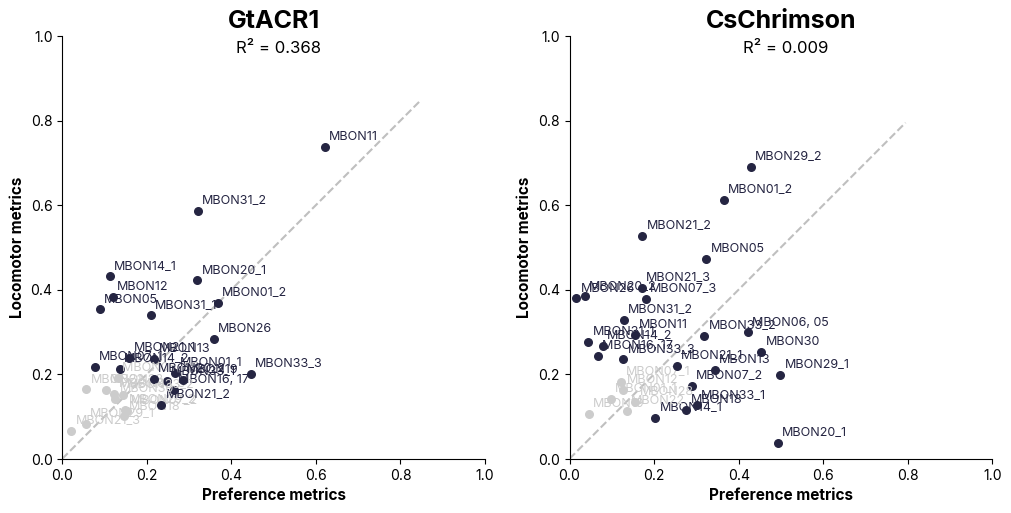

In [29]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (pref_acr,loco_acr, 'GtACR1'),
    (pref_chr, loco_chr, 'CsChrimson')
]

USE_MBON_NUMBERS = True
label_map = dict(zip(mbons, rename_labels(mbons, USE_MBON_NUMBERS)))

highlight_color = "#252542"
grey_color = "#CCCCCC"

fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.2})


for ax, (x, y, title), label in zip(axes, panels, ['A', 'B']):
    ax.set_aspect('equal', adjustable='box')
    for mbon in mbons:
        if x[mbon] < 0.2 and y[mbon] < 0.2:
            color = grey_color
        else:
            color = highlight_color
        ax.scatter(x[mbon], y[mbon], s=30, color=color, zorder=3)
        ax.annotate(label_map[mbon], (x[mbon], y[mbon]), fontsize=9, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points', color=color)

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.41, 0.96, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=12)

    ax.set_xlabel(f'Preference metrics', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Locomotor metrics', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}', fontsize=18, fontweight='bold', loc='center')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\phenomics" + date +".svg", bbox_inches='tight')
plt.show()

## Locomotion only

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'

x = loco_acr
y = loco_chr

label_map = dict(zip(mbons, rename_labels(mbons, USE_MBON_NUMBERS)))

fig, ax = plt.subplots(figsize=(8, 8))

for mbon in mbons:
    if x[mbon] < 0.2 and y[mbon] < 0.2:
        color = 'gray'
    else:
        color = "#1A1968"
    ax.scatter(x[mbon], y[mbon], s=40, color=color, zorder=3)
    ax.annotate(label_map[mbon], (x[mbon], y[mbon]), fontsize=12, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points', color=color)

lim = max(x.max(), y.max()) * 1.15
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)

# r_squared = stats.pearsonr(x, y)[0] ** 2
# ax.text(0.05, 0.92, f'R² = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

ax.set_xlabel('GtACR1 Locomotor mean |g|', fontsize=16)
ax.set_ylabel('CsChrimson Locomotor mean |g|', fontsize=16)
# ax.set_title('Locomotor metrics', fontsize=16, fontweight='bold', loc='left')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()
plt.show()

In [29]:
df_total = pd.DataFrame()
df_total["Preference mean_ACR"] = pref_acr
df_total["Preference mean_Chrimson2"] = pref_chr
df_total["Locomotor mean_ACR"] = loco_acr
df_total["Locomotor mean_Chrimson2"] =loco_chr
df_total["Combined mean_ACR"] = comb_acr
df_total["Combined mean_Chrimson2"] = comb_chr


In [30]:
pref_cols = ["PI_Hg_OSAR", "Light Attraction Index_Hg_OSAR"]
loco_cols = ["Log2 Bout Speed ratio_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR", "Max Velocity ratio_Hg_OSAR"]
all_cols = pref_cols + loco_cols

acr_means = acr[all_cols].abs().mean()
chr_means = chrimson[all_cols].abs().mean()
acr_stds = acr[all_cols].abs().std()
chr_stds = chrimson[all_cols].abs().std()
n_acr_count = acr[all_cols].count()
n_chr_count = chrimson[all_cols].count()

ci95_acr_val = 1.96 * acr_stds / np.sqrt(n_acr_count)
ci95_chr_val = 1.96 * chr_stds / np.sqrt(n_chr_count)

group = ["preference"] * len(pref_cols) + ["locomotor"] * len(loco_cols)

result_osar = pd.DataFrame({
    "metric": all_cols,
    "group": group,
    "GtACR1": acr_means.values,
    "GtACR1_CI_low": (acr_means - ci95_acr_val).values,
    "GtACR1_CI_high": (acr_means + ci95_acr_val).values,
    "CsChrimson": chr_means.values,
    "CsChrimson_CI_low": (chr_means - ci95_chr_val).values,
    "CsChrimson_CI_high": (chr_means + ci95_chr_val).values,
})
result_osar

,metric,group,GtACR1,GtACR1_CI_low,GtACR1_CI_high,CsChrimson,CsChrimson_CI_low,CsChrimson_CI_high
0,PI_Hg_OSAR,preference,0.212199,0.160767,0.263631,0.241175,0.178092,0.304258
1,Light Attraction Index_Hg_OSAR,preference,0.192826,0.119755,0.265897,0.199506,0.139579,0.259432
2,Log2 Bout Speed ratio_Hg_OSAR,locomotor,0.354883,0.257828,0.451938,0.306794,0.219054,0.394534
3,Bout Number Index_Hg_OSAR,locomotor,0.190561,0.133667,0.247455,0.326960,0.201543,0.452376
4,Bout Duration ratio_Hg_OSAR,locomotor,0.195924,0.140204,0.251643,0.206149,0.156851,0.255446
5,Max Velocity ratio_Hg_OSAR,locomotor,0.226799,0.123585,0.330014,0.236932,0.172867,0.300997


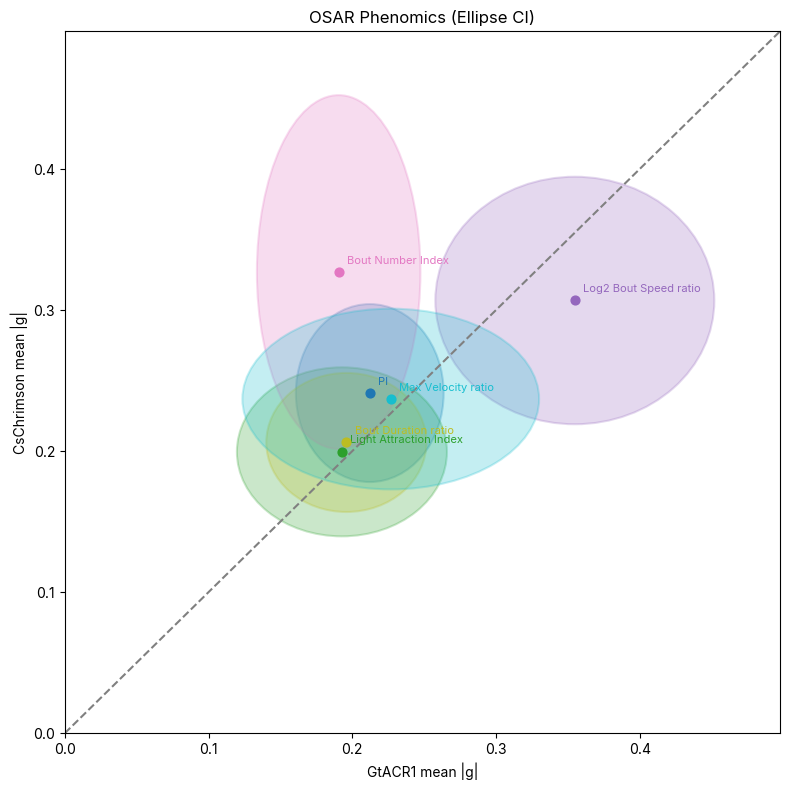

In [31]:
from matplotlib.patches import Ellipse

colors = plt.cm.tab10(np.linspace(0, 1, len(result_osar)))

fig, ax = plt.subplots(figsize=(8, 8))

for i, row in result_osar.iterrows():
    w = row["GtACR1_CI_high"] - row["GtACR1_CI_low"]
    h = row["CsChrimson_CI_high"] - row["CsChrimson_CI_low"]
    ellipse = Ellipse((row["GtACR1"], row["CsChrimson"]), width=w, height=h,
                       facecolor=colors[i], alpha=0.25, edgecolor=colors[i], linewidth=1.5)
    ax.add_patch(ellipse)
    ax.scatter(row["GtACR1"], row["CsChrimson"], color=colors[i], s=40, zorder=3)
    label = row["metric"].replace("_Hg_OSAR", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8, color=colors[i])

max_val = max(result_osar["GtACR1_CI_high"].max(), result_osar["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("GtACR1 mean |g|")
ax.set_ylabel("CsChrimson mean |g|")
ax.set_title("OSAR Phenomics (Ellipse CI)")
plt.tight_layout()
plt.show()

In [15]:
import dabest

pref_long = pd.DataFrame({
    'MBON': list(mbons) * 2,
    'Responder': ['CsChrimson'] * len(mbons) + ['GtACR1'] * len(mbons),
    'Metric': 'Preference',
    'Value': list(pref_chr.loc[mbons].values) + list(pref_acr.loc[mbons].values),
})

loco_long = pd.DataFrame({
    'MBON': list(mbons) * 2,
    'Responder': ['CsChrimson'] * len(mbons) + ['GtACR1'] * len(mbons),
    'Metric': 'Locomotion',
    'Value': list(loco_chr.loc[mbons].values) + list(loco_acr.loc[mbons].values),
})

dabest_long = pd.concat([pref_long, loco_long], ignore_index=True)
dabest_long['ID'] = dabest_long.groupby(['MBON', 'Metric']).ngroup() + 1
dabest_long

,MBON,Responder,Metric,Value,ID
0,SS77442,CsChrimson,Preference,0.045546,46
1,SS01194,CsChrimson,Preference,0.275966,26
2,SS75199,CsChrimson,Preference,0.300779,40
3,MB112C,CsChrimson,Preference,0.154700,10
4,SS01298,CsChrimson,Preference,0.066406,28
...,...,...,...,...,...
119,SS46348,GtACR1,Locomotion,0.239020,31
120,MB210B,GtACR1,Locomotion,0.203149,11
121,SS80958,GtACR1,Locomotion,0.283247,51
122,SS67741,GtACR1,Locomotion,0.421781,37


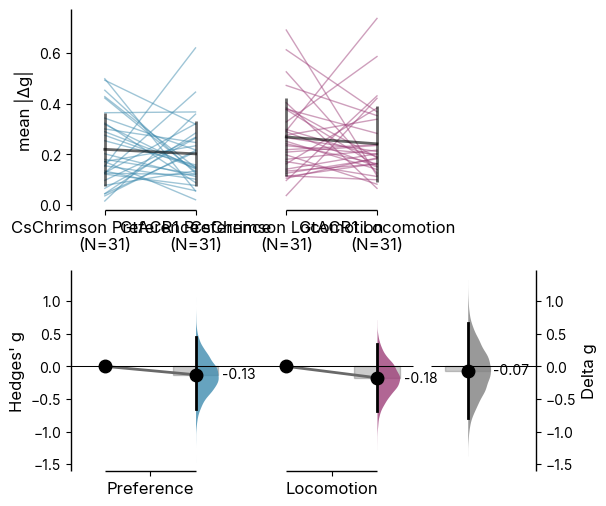

In [24]:
paired_delta2 = dabest.load(
    data=dabest_long,
    x=["Responder", "Metric"],
    y="Value",
    delta2=True,
    experiment="Metric",
    x1_level=["CsChrimson", "GtACR1"],
    paired="baseline",
    id_col="ID"
)

palette = {'Preference': "#408CAF", 'Locomotion': "#9E407A"}
genoListNL = ['Preference', 'Locomotion']

compare = paired_delta2.hedges_g.plot(
    color_col='Metric', custom_palette=palette,
    raw_desat=1, contrast_desat=1
)

#compare.axes[0].set_xticklabels(["CsChrimson", "GtACR1", "CsChrimson", "GtACR1"])
compare.axes[0].set_ylabel("mean |Δg|")
compare.axes[1].set_ylabel("Hedges' g")
compare.axes[0].get_legend().remove()
compare.axes[1].spines['bottom'].set_visible(False)
compare.axes[1].set_xticks([0.5, 2.5])
compare.axes[1].set_xticklabels(genoListNL, fontsize=12)

for i in range(len(genoListNL)):
    compare.axes[1].collections[i].set_color(palette[genoListNL[i]])


mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "dabestprefvslocomotion.svg", bbox_inches="tight")
plt.show()

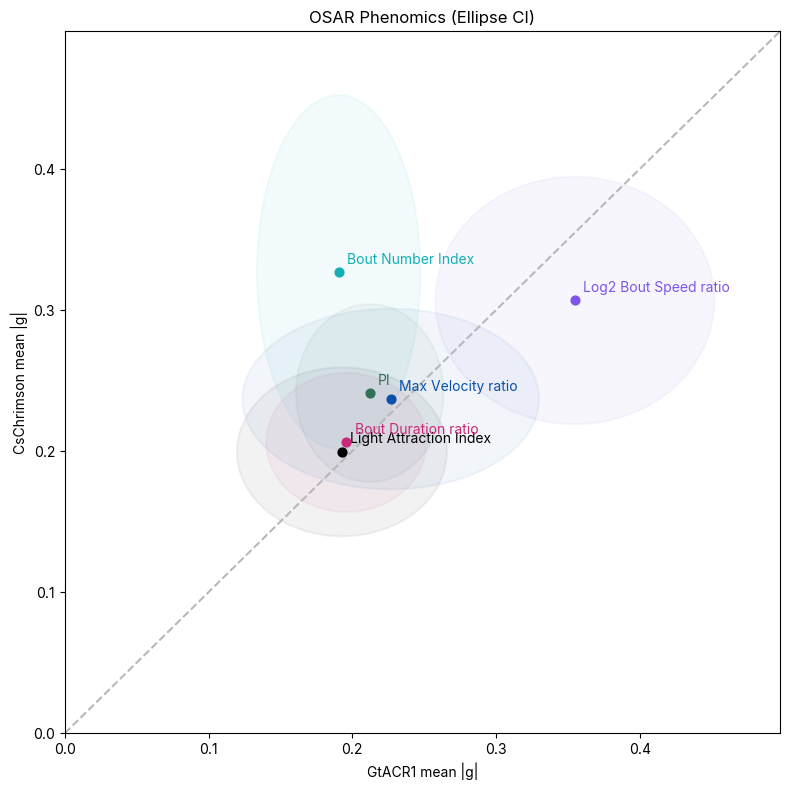

In [34]:
from matplotlib.patches import Ellipse
## Metric ellipse shading
colors = [
    "#347057",
    '#000000',
    "#7D56E9",
    "#13AFB4",
    "#CA297A",
    "#0A51AD",
]

fig, ax = plt.subplots(figsize=(8, 8))

for i, row in result_osar.iterrows():
    w = row["GtACR1_CI_high"] - row["GtACR1_CI_low"]
    h = row["CsChrimson_CI_high"] - row["CsChrimson_CI_low"]
    ellipse = Ellipse((row["GtACR1"], row["CsChrimson"]), width=w, height=h,
                       facecolor=colors[i], alpha=0.05, edgecolor=colors[i], linewidth=1.5)
    ax.add_patch(ellipse)
    ax.scatter(row["GtACR1"], row["CsChrimson"], color=colors[i], s=40, zorder=3)
    label = row["metric"].replace("_Hg_OSAR", "")
    ax.annotate(label, (row["GtACR1"], row["CsChrimson"]),
                textcoords="offset points", xytext=(6, 6), fontsize=10, color=colors[i])

max_val = max(result_osar["GtACR1_CI_high"].max(), result_osar["CsChrimson_CI_high"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], linestyle="--", color="#B8B8B8")

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("GtACR1 mean |g|")
ax.set_ylabel("CsChrimson mean |g|")
ax.set_title("OSAR Phenomics (Ellipse CI)")
plt.tight_layout()

mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "metric shading.svg", bbox_inches="tight")
plt.show()

plt.show()

## combined phenomics

In [46]:
specifiedpath = "D:\\"
filepath_total = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx"

df_total_raw = pd.read_excel(filepath_total)
df_total_raw = df_total_raw[~df_total_raw['MBON'].isin(['VT999036', 'R76B09'])]

acr_t = df_total_raw[df_total_raw['responder'] == 'ACR'].set_index('MBON')
chr_t = df_total_raw[df_total_raw['responder'] == 'Chrimson2'].set_index('MBON')
mbons_t = acr_t.index.intersection(chr_t.index)
acr_t = acr_t.loc[mbons_t]
chr_t = chr_t.loc[mbons_t]

locomotor_metrics_OSAR = [
    'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
    'Bout Number Index_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
]
locomotor_metrics_climbing = [
    'Average height climbed_Δg_Falling', 'Straightness Index_Δg_Falling',
    'Bout speed_Δg_Falling', 'Duration of bouts_Δg_Falling',
    'Number of Bouts_Δg_Falling', 'Max velocity_Δg_Falling',
]

osar_acr = acr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
osar_chr = chr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
climb_acr = acr_t[locomotor_metrics_climbing].abs().mean(axis=1)
climb_chr = chr_t[locomotor_metrics_climbing].abs().mean(axis=1)

combined_acr = (osar_acr + climb_acr) * 0.5
combined_chr = (osar_chr + climb_chr) * 0.5

pref_acr_t = acr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)
pref_chr_t = chr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)

effect_threshold = 0.35
high_acr = (osar_acr >= effect_threshold) | (climb_acr >= effect_threshold)
high_chr = (osar_chr >= effect_threshold) | (climb_chr >= effect_threshold)

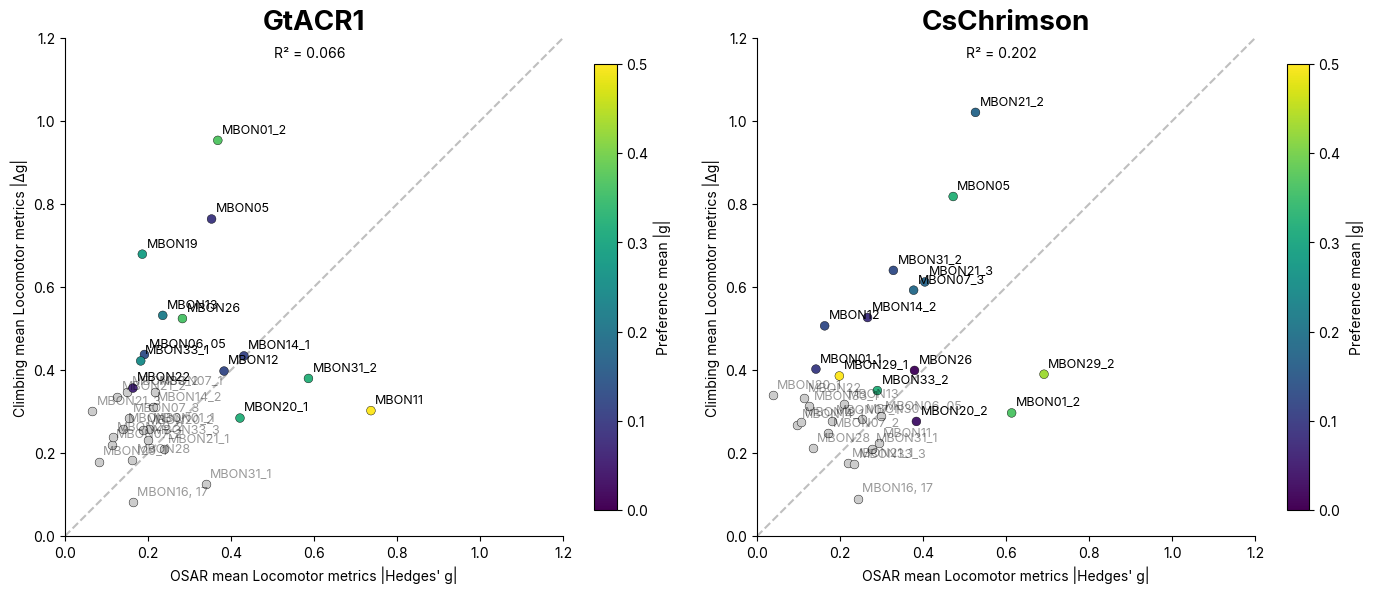

In [47]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (osar_acr, climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]

USE_MBON_NUMBERS = True
label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (x, y, c_val, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    sc = ax.scatter(x[mask], y[mask], s=40, c=c_val[mask], cmap='viridis', zorder=3, edgecolors='k', vmin = 0, vmax = 0.5, linewidth=0.3)
    #sc = ax.scatter(x[mask], y[mask], s=40, c="#1960E6", zorder=3, edgecolors='k', linewidth=0.3)
    plt.colorbar(sc, ax=ax, label='Preference mean |g|', shrink=0.8)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=9, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.plot([0, 5], [0, 5], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.42, 0.96, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel("OSAR mean Locomotor metrics |Hedges' g|", fontsize=10)
    ax.set_ylabel('Climbing mean Locomotor metrics |\u0394g|', fontsize=10)
    ax.set_title(f'{title}', fontsize=20, fontweight='bold', loc='center')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
#plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "fallingvsosar.svg", bbox_inches="tight")
plt.show()

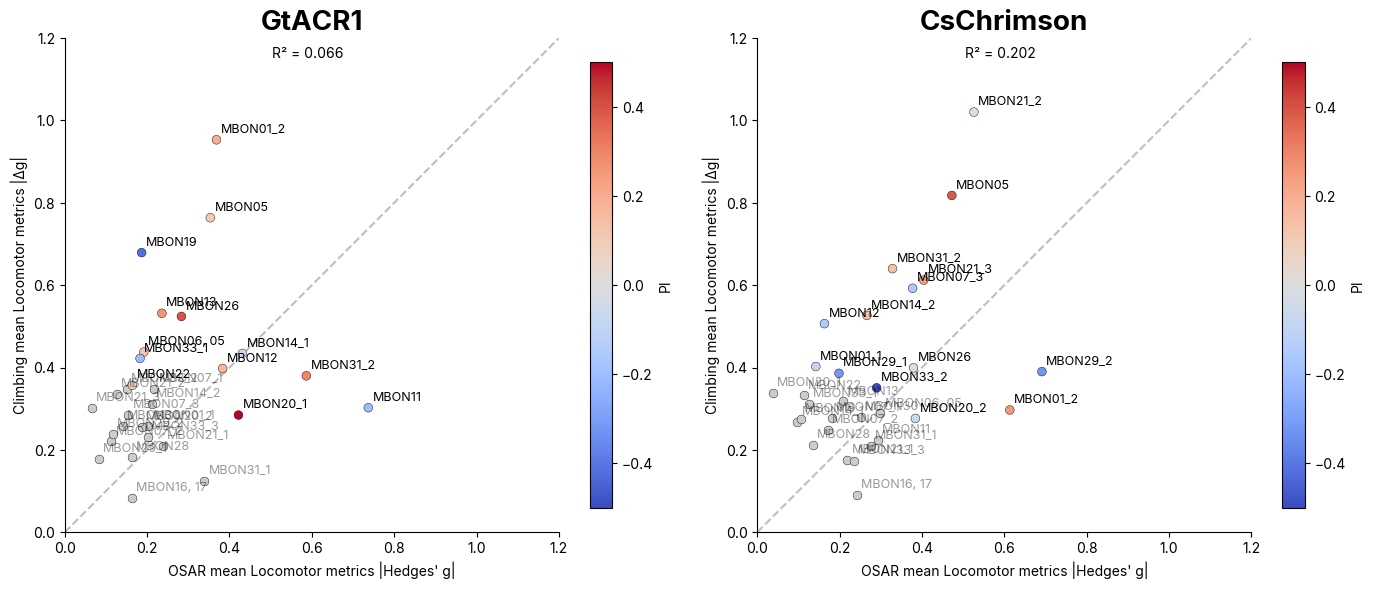

In [49]:
mpl.rcParams['svg.fonttype'] = 'none'

# Choose: 'PI_Hg_OSAR' or 'Light Attraction Index_Hg_OSAR'
color_metric = 'PI_Hg_OSAR'
color_label = 'PI' if color_metric == 'PI_Hg_OSAR' else 'LAI'

color_acr = acr_t[color_metric]
color_chr = chr_t[color_metric]

panels = [
    (osar_acr, climb_acr, color_acr, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, color_chr, high_chr, 'CsChrimson'),
]

USE_MBON_NUMBERS = True
label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (x, y, c_val, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    sc = ax.scatter(x[mask], y[mask], s=40, c=c_val[mask], cmap='coolwarm', zorder=3, edgecolors='k', vmin=-0.5, vmax=0.5, linewidth=0.3)
    plt.colorbar(sc, ax=ax, label=color_label, shrink=0.8)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=9, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    ax.plot([0, 5], [0, 5], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.42, 0.96, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel("OSAR mean Locomotor metrics |Hedges' g|", fontsize=10)
    ax.set_ylabel('Climbing mean Locomotor metrics |\u0394g|', fontsize=10)
    ax.set_title(f'{title}', fontsize=20, fontweight='bold', loc='center')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
plt.show()

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'
fig, ax = plt.subplots(figsize=(8, 8))

high_combined = high_acr & high_chr
pref_combined = (pref_acr_t + pref_chr_t) / 2

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

ax.scatter(combined_acr[~high_combined], combined_chr[~high_combined], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
sc = ax.scatter(combined_acr[high_combined], combined_chr[high_combined], s=40, c=pref_combined[high_combined], cmap='viridis', zorder=3, edgecolors='k', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='Preference mean |g|', shrink=0.8)

for mbon in mbons_t:
    ax.annotate(label_map_t[mbon], (combined_acr[mbon], combined_chr[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points', alpha=1.0 if high_combined[mbon] else 0.4)

lim = max(combined_acr.max(), combined_chr.max()) * 1.15
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

r_squared = stats.pearsonr(combined_acr, combined_chr)[0] ** 2
ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

ax.set_xlabel('GtACR1 Combined mean |g|', fontsize=10)
ax.set_ylabel('CsChrimson Combined mean |g|', fontsize=10)
ax.set_title('Combined OSAR + Climbing Locomotor', fontsize=16, fontweight='bold', loc='left')
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

mpl.rcParams['svg.fonttype'] = 'none'

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig = plt.figure(figsize=(18, 7))

for col, (o, c, p, mask, title) in enumerate([
    (osar_acr, climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    ax.scatter(o[~mask], c[~mask], p[~mask], s=40, color='#CCCCCC', zorder=2)
    ax.scatter(o[mask], c[mask], p[mask], s=40, color="#5F5DFF", zorder=3)
    for mbon in mbons_t:
        ax.text(o[mbon], c[mbon], p[mbon], label_map_t[mbon], fontsize=7, alpha=1.0 if mask[mbon] else 0.3)
    ax.set_xlabel('OSAR Locomotor |g|', fontsize=9)
    ax.set_ylabel('Climbing Locomotor |g|', fontsize=9)
    ax.set_zlabel('OSAR Preference |g|', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (climb_acr, pref_acr_t, high_acr, 'GtACR1'),
    (climb_chr, pref_chr_t, high_chr, 'CsChrimson'),
]

label_map_t = dict(zip(mbons_t, rename_labels(mbons_t, USE_MBON_NUMBERS)))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, mask, title), label in zip(axes, panels, ['A', 'B']):
    ax.scatter(x[~mask], y[~mask], s=40, color='#CCCCCC', zorder=2, edgecolors='k', linewidth=0.3)
    ax.scatter(x[mask], y[mask], s=40, color="#5F5DFF", zorder=3, edgecolors='k', linewidth=0.3)

    for mbon in mbons_t:
        ax.annotate(label_map_t[mbon], (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=1.0 if mask[mbon] else 0.4)

    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel('Climbing Locomotor mean |g|', fontsize=10)
    ax.set_ylabel('Preference mean |g|', fontsize=10)
    ax.set_title(f'{label}. {title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()